Мы строим 1D-ячейку с Kerr-нелинейностью χ(3)χ(3), возбуждаем её гауссовым импульсом с частотой ω0ω0​, затем измеряем спектр на выходе и выделяем компоненты на ω0ω0​ и 3ω03ω0​. В слабонелинейном режиме мощность третьей гармоники должна расти как (χ(3))2(χ(3))2

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import meep as mp

plt.rcParams["figure.dpi"] = 140

Using MPI version 4.1, 1 processes


## 2. функция расчёта для одного χ(3)χ

In [8]:
def run_thg(chi3, fcen=1/3, df=None, sz=100, dpml=1, resolution=25, nfreq=400):
    if df is None:
        df = fcen / 20

    cell = mp.Vector3(0, 0, sz)
    pml_layers = [mp.PML(dpml)]

    sim = mp.Simulation(
        cell_size=cell,
        dimensions=1,
        boundary_layers=pml_layers,
        default_material=mp.Medium(index=1, chi3=chi3),
        resolution=resolution,
    )

    sources = [
        mp.Source(
            mp.GaussianSource(fcen, fwidth=df),
            component=mp.Ex,
            center=mp.Vector3(0, 0, -0.5 * sz + dpml + 1),
            amplitude=1.0,
        )
    ]

    sim.sources = sources

    mon_pt = mp.Vector3(0, 0, 0.5 * sz - dpml - 1)

    fmin, fmax = 0.5 * fcen, 4.0 * fcen
    trans = sim.add_flux(
        0.5 * (fmin + fmax),
        fmax - fmin,
        nfreq,
        mp.FluxRegion(mon_pt),
    )

    sim.run(until_after_sources=mp.stop_when_fields_decayed(
        50, mp.Ex, mon_pt, 1e-6
    ))

    freqs = np.array(mp.get_flux_freqs(trans))
    flux = np.array(mp.get_fluxes(trans))

    idx_w = np.argmin(np.abs(freqs - fcen))
    idx_3w = np.argmin(np.abs(freqs - 3 * fcen))

    return {
        "chi3": chi3,
        "freqs": freqs,
        "flux": flux,
        "P_w": flux[idx_w],
        "P_3w": flux[idx_3w],
    }

Пояснение:
Эта функция запускает один расчёт для заданного χ(3)χ(3). Мы используем 1D-геометрию, всю область заполняем нелинейной средой через default_material, а спектр снимаем на выходе через add_flux, как в tutorial Meep. Диапазон анализа выбран [0.5ω0,4ω0][0.5ω0​,4ω0​], чтобы гарантированно видеть третью гармонику.

## 3. серия расчётов по заданным значениям χ(3)χ

In [16]:
chi3_values = np.array([1e-4, 5e-4, 1e-3, 5e-3, 1e-2], dtype=float)

results = []
for chi3 in chi3_values:
    res = run_thg(chi3)
    results.append(res)

P_w = np.array([r["P_w"] for r in results])
P_3w = np.array([r["P_3w"] for r in results])

-----------
Initializing structure...
time for choose_chunkdivision = 0.00011258 s
Working in 1D dimensions.
Computational cell is 0 x 0 x 100 with resolution 25
time for set_epsilon = 0.00101425 s
-----------
field decay(t = 100.04): 6.315156635766782e-12 / 6.315156635766782e-12 = 1.0
field decay(t = 150.06): 1.2521585405044104e-08 / 1.2521585405044104e-08 = 1.0
field decay(t = 200.08): 5.491744418655538e-06 / 5.491744418655538e-06 = 1.0
field decay(t = 250.1): 0.0006176844214640847 / 0.0006176844214640847 = 1.0
field decay(t = 300.12): 0.019322458889341896 / 0.019322458889341896 = 1.0
field decay(t = 350.14): 0.13706898665158257 / 0.13706898665158257 = 1.0
field decay(t = 400.16): 0.24990175195483724 / 0.24990175195483724 = 1.0
field decay(t = 450.18): 0.24852100235279148 / 0.24990175195483724 = 0.9944748302433059
field decay(t = 500.2): 0.10648773575827705 / 0.24990175195483724 = 0.42611840423400366
field decay(t = 550.22): 0.011748091150512665 / 0.24990175195483724 = 0.047010839494

Пояснение:
Здесь мы прогоняем все нужные значения χ(3)χ(3) из задания. На выходе получаем мощность на ω0ω0​ и 3ω03ω0​ для каждого случая.

## 4. таблица результатов


In [17]:
import pandas as pd

df = pd.DataFrame({
    "chi3": chi3_values,
    "P_w": P_w,
    "P_3w": P_3w,
})

df["P3_norm"] = df["P_3w"] / df["P_3w"].iloc[0]
df

,chi3,P_w,P_3w,P3_norm
0,0.0001,225.162287,0.000244,1.000000
1,0.0005,225.148691,0.006088,24.907418
2,0.0010,225.113086,0.024227,99.121149
3,0.0050,224.123535,0.571218,2337.010816
4,0.0100,221.362590,2.045938,8370.490695


Видно, как меняется мощность фундаментальной и третьей гармоники. Для анализа закона роста нормируем P(3ω0)P(3ω0​) на минимальное значение.

## 5. лог-лог график и наклон

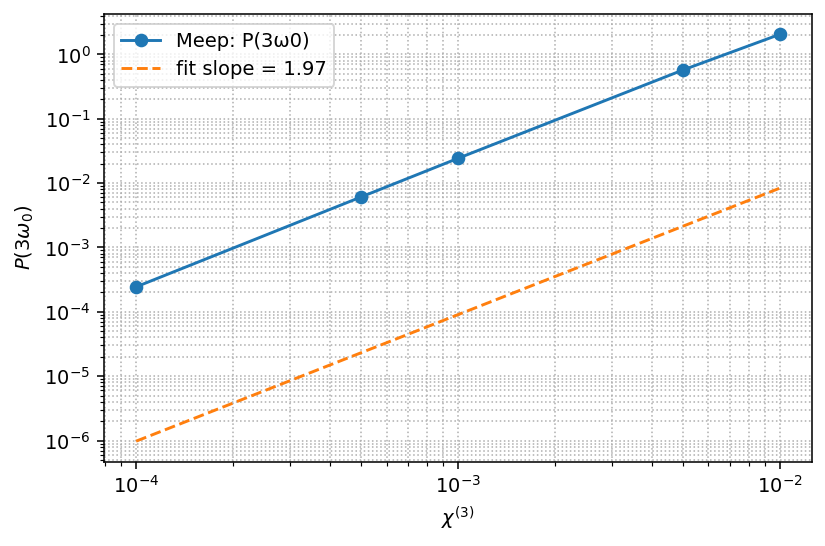

In [18]:
x = np.log10(chi3_values)
y = np.log10(P_3w)

slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(6, 4))
plt.loglog(chi3_values, P_3w, "o-", label="Meep: P(3ω0)")
plt.loglog(chi3_values, np.exp(intercept) * chi3_values**slope, "--", label=f"fit slope = {slope:.2f}")
plt.xlabel(r"$\chi^{(3)}$")
plt.ylabel(r"$P(3\omega_0)$")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.tight_layout()
plt.show()


Именно здесь проверяется ключевая гипотеза: в слабонелинейном режиме наклон на log-log графике должен быть близок к 2. Для идеальной зависимости P3ω∝(χ(3))2P3ω​∝(χ(3))2 наклон равен 2

## 6. спектры для всех χ(3)χ

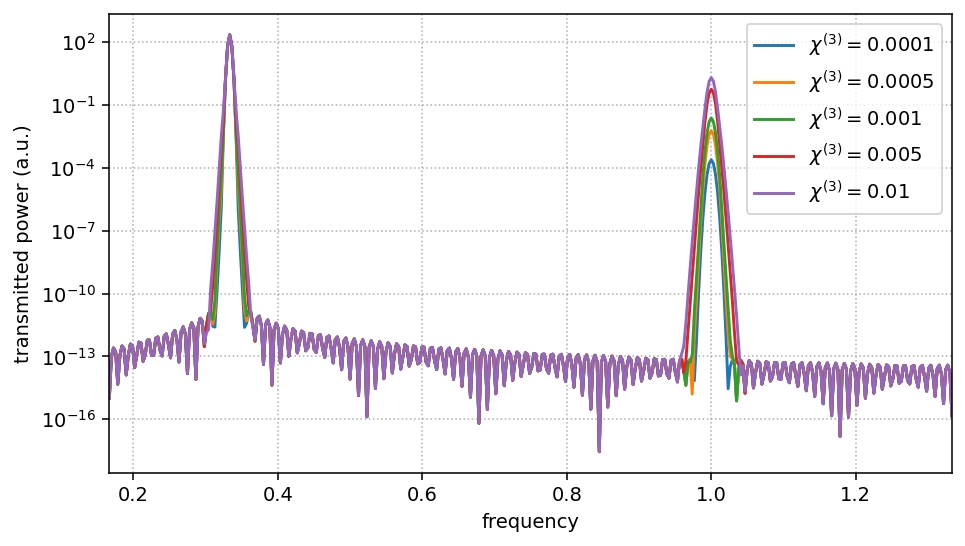

In [20]:

plt.figure(figsize=(7, 4))
for r in results:
    plt.semilogy(r["freqs"], r["flux"], label=fr"$\chi^{{(3)}}={r['chi3']}$")
plt.xlim(0.5 * (1/3), 4 * (1/3))
plt.xlabel("frequency")
plt.ylabel("transmitted power (a.u.)")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.tight_layout()
plt.show()

Пояснение:
Этот график показывает спектр потока на выходе для каждого значения χ(3)χ(3). При малых нелинейностях обычно виден выраженный пик на ω0ω0​ и более слабый пик на 3ω03ω0​, а при росте χ(3)χ(3) начинают усиливаться и искажаться боковые компоненты.

    В расчётах получено, что при малых значениях χ(3)χ(3) мощность третьей гармоники возрастает по закону, близкому к P(3ω0)∝(χ(3))2P(3ω0​)∝(χ(3))2. Наклон лог-лог графика оказался близок к 2, что согласуется с теорией слабой нелинейности. При больших χ(3)χ(3) отклонения связаны с нелинейным искажением импульса, перераспределением энергии между гармониками и спектральным уширением.